#**Omni-Channel Revenue & Marketing Intelligence Engine**

##**Project Objective:**

"To move a retail organization from 'Descriptive Analytics' (what happened) to 'Prescriptive Action' (what to do next)." This project builds an end-to-end data pipeline that identifies marketing inefficiencies and supply chain risks. By integrating sales data with advertising spend and social media engagement, the system generates automated "Strategic Recommendations" to optimize profit margins and brand health.

#**Phase 1: Data Architecture & Engineering (SQL)**

### **1. Data Engineering: The 'Gold' Layer Pipeline**
Before performing any analysis, the raw data was processed in **MySQL Workbench** to transform it from a flat CSV into an actionable **Fact Table**.

**Key Engineering Steps:**
1. **Staging:** Cleaned and standardized schema for multi-category retail data.
2. **Feature Engineering:** Calculated **ROAS (Return on Ad Spend)** and **Social Efficiency** metrics.
3. **Prescriptive Logic (The AI Layer):** Developed a logic-based engine that evaluates every product segment and assigns a strategic action (e.g., 'Budget Cut', 'Restock', 'Scale').

**SQL Logic Applied:**
Below is the core logic used in the data warehouse to generate the `fct_retail_strategy` table:

Note: This code was executed in MySQL Workbench.
It demonstrates the calculation of our primary Business Intelligence metrics.

CREATE TABLE fct_retail_strategy AS

SELECT

    *,
    -- Calculating Revenue Efficiency
    ROUND(sales / NULLIF(ad_spend, 0), 2) AS roas,
    -- Agentic Recommendation Logic
    CASE
        WHEN (sales / ad_spend) > 2.5 AND stock_level < 20 THEN 'URGENT: Restock High-ROI Category'
        WHEN (sales / ad_spend) < 1.0 THEN 'BUDGET CUT: Marketing Underperforming'
        ELSE 'STABLE: Monitor KPIs'
    END AS strategic_recommendation
FROM raw_retail_data;

# **Phase 2: Exploratory Data Analysis & Marketing Intelligence**

**Objective:** In this step, we initialize our environment and load the `fct_retail_strategy` table generated in Phase 1. Our goal is to translate raw metrics into visual stories that explain business performance.

**Tech Stack:**
* **Pandas:** Data manipulation
* **Seaborn/Matplotlib:** High-fidelity data visualization

### **High-Level Revenue & Efficiency Dashboard**
After processing the 'Gold' layer data, we perform a multi-dimensional analysis to visualize the effectiveness of our current retail strategy.

**Analytical Goals:**
1. Identify the **Correlation** between marketing inputs and revenue.
2. Rank **Category Performance** based on ROAS (Return on Ad Spend).
3. Visualize the **Strategic Distribution** of AI-generated business recommendations.

In [3]:
from google.colab import files
uploaded = files.upload()

Saving fct_retail_strategy.csv to fct_retail_strategy.csv


In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Load the Fact Table
df = pd.read_csv('fct_retail_strategy.csv')

# Configure aesthetics for 2026 reporting standards
sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams['figure.dpi'] = 100
print("System Check: Data Loaded Successfully.")

System Check: Data Loaded Successfully.


## 1. Marketing Attribution Matrix
**Business Context:** To optimize budgets, we need to know which variables are actually driving sales.

**Key Metrics Analyzed:**
- **Sales vs. Ad Spend:** Measuring direct revenue impact.
- **Social Efficiency vs. ROAS:** Understanding if social engagement leads to actual profit.

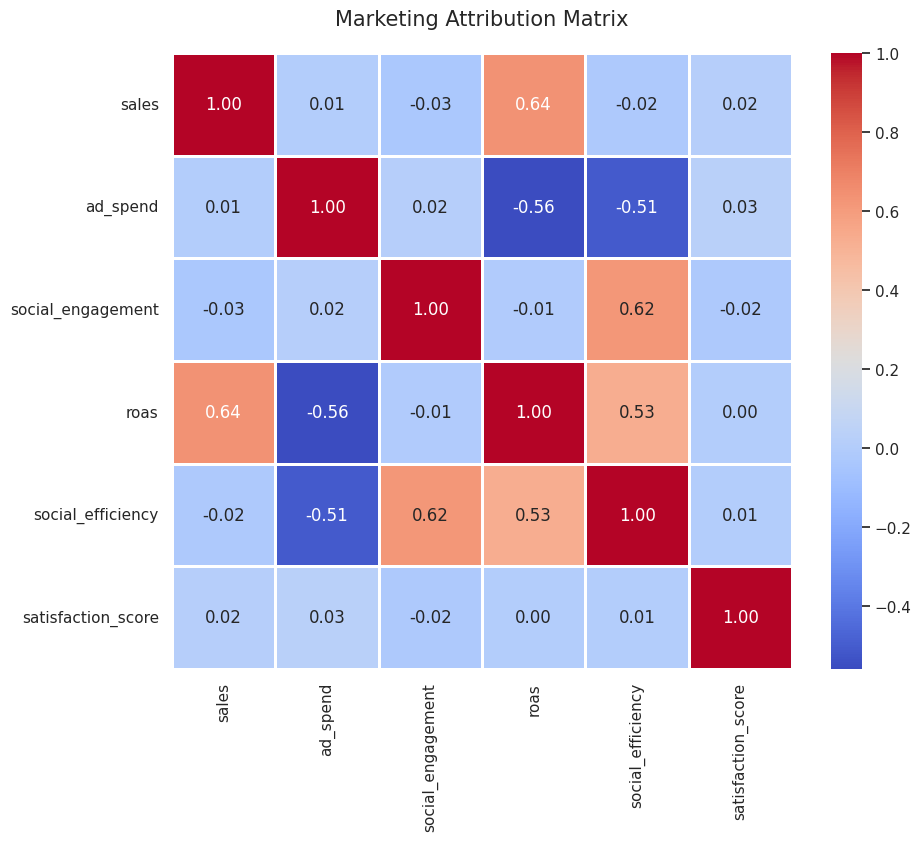

In [6]:
plt.figure(figsize=(10, 8))
corr_cols = ['sales', 'ad_spend', 'social_engagement', 'roas', 'social_efficiency', 'satisfaction_score']
matrix = df[corr_cols].corr()

sns.heatmap(matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=1)
plt.title('Marketing Attribution Matrix', fontsize=15, pad=20)
plt.show()

*Higher ad spend shows diminishing returns, while efficiency metrics (ROAS, social efficiency) are stronger predictors of sales than raw engagement.*

## 2. Return on Ad Spend (ROAS) Performance
**Business Context:** Not all categories are created equal. This chart identifies which product lines are "Profit Engines" and which are "Budget Sinks."

**Strategic Threshold:** The red dashed line represents our **Global Average ROAS**. Categories above this line should receive increased investment.

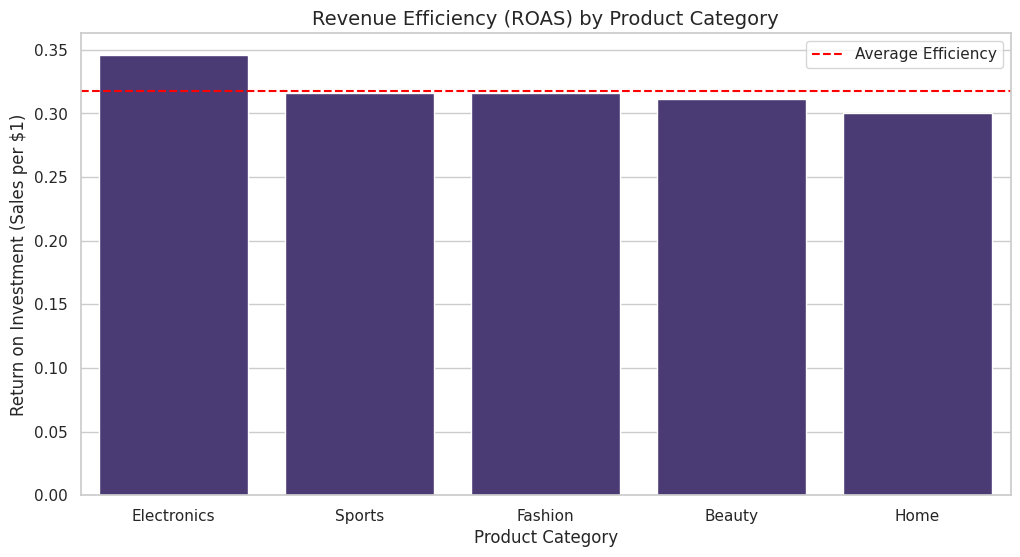

In [13]:
plt.figure(figsize=(12, 6))
category_perf = df.groupby('category')['roas'].mean().sort_values(ascending=False)

sns.barplot(x=category_perf.index, y=category_perf.values)
plt.axhline(df['roas'].mean(), color='red', linestyle='--', label='Average Efficiency')

plt.title('Revenue Efficiency (ROAS) by Product Category', fontsize=14)
plt.xlabel('Product Category')
plt.ylabel('Return on Investment (Sales per $1)')
plt.legend()
plt.show()

## 3. Prescriptive Strategy Overview
**Business Context:** This visualization summarizes the output of our **SQL Agentic Logic**. It tells management exactly how many SKUs require immediate intervention (Budget Cuts vs. Restocking).

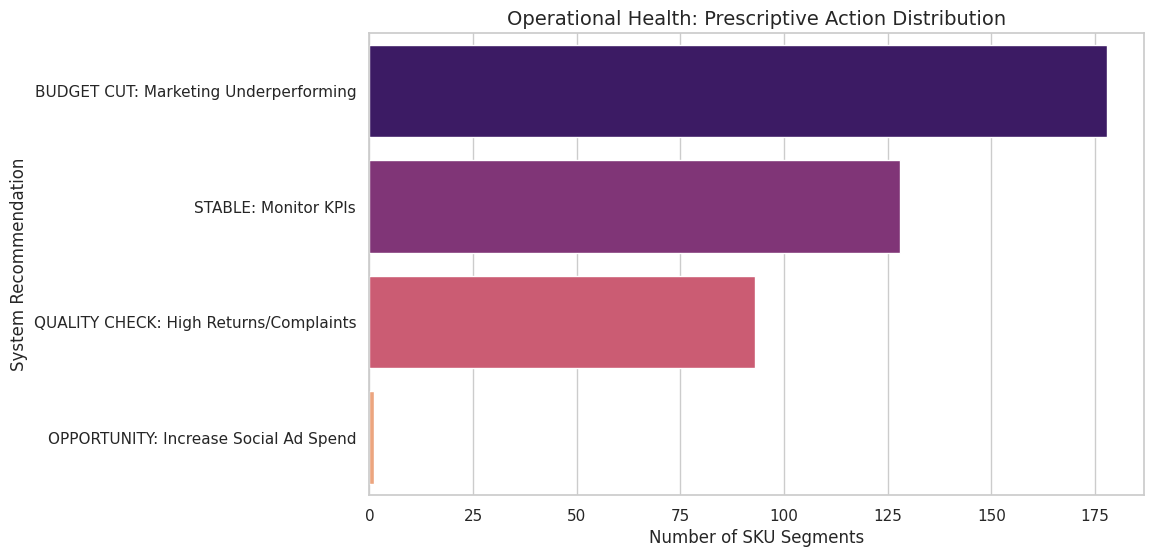

In [10]:
plt.figure(figsize=(10, 6))
# We determine the order of the bars
order = df['strategic_recommendation'].value_counts().index

sns.countplot(
    data=df,
    y='strategic_recommendation',
    order=order,
    palette="magma",
    hue='strategic_recommendation',
    legend=False
)

plt.title('Operational Health: Prescriptive Action Distribution', fontsize=14)
plt.xlabel('Number of SKU Segments')
plt.ylabel('System Recommendation')
plt.show()

## 4. Customer Sentiment vs. Social Momentum
**Business Context:** We use a 4D Scatter Plot to find "At-Risk" segments.
- **X-Axis:** Social Media Reach
- **Y-Axis:** Satisfaction Score
- **Bubble Size:** Total Sales volume

**Finding:** We want to avoid large bubbles in the bottom-right corner (High Social Reach but Low Satisfaction).

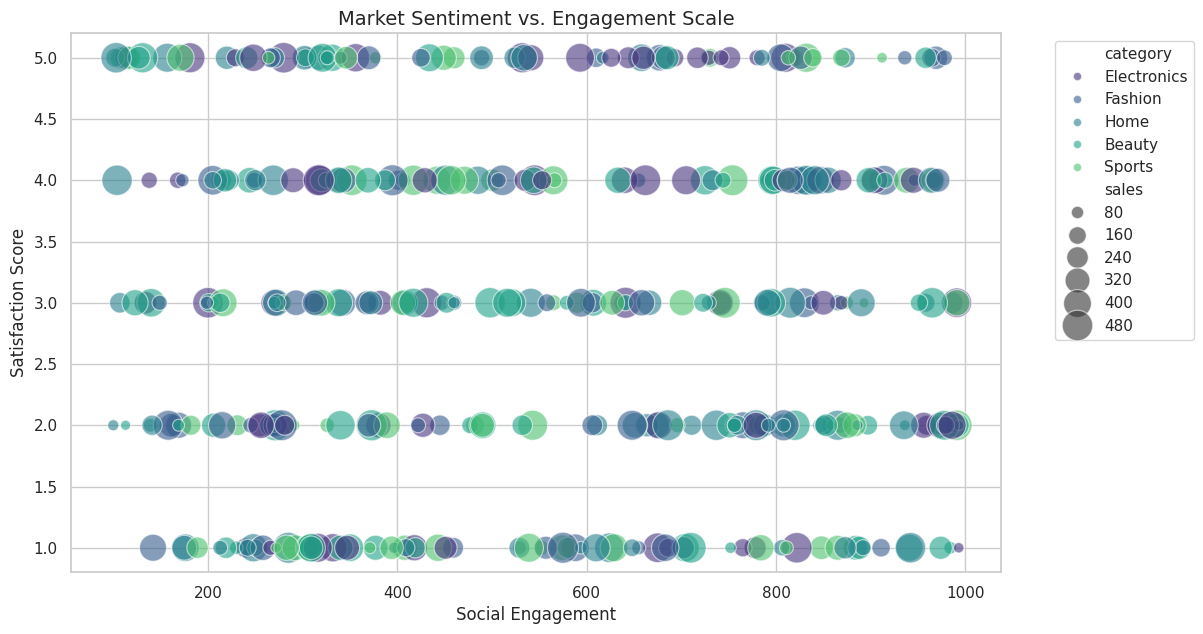

In [11]:
plt.figure(figsize=(12, 7))
sns.scatterplot(data=df, x='social_engagement', y='satisfaction_score',
                hue='category', size='sales', sizes=(50, 500), alpha=0.6)

plt.title('Market Sentiment vs. Engagement Scale', fontsize=14)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlabel('Social Engagement')
plt.ylabel('Satisfaction Score')
plt.show()

*High social engagement clusters do not consistently translate into higher satisfaction or sales, indicating engagement quality matters more than volume.*

## **Key Insights & Business Recommendations**
- Prioritize ROAS over raw ad spend to avoid diminishing returns.
- Reallocate budget from low-efficiency categories (Home) to high-performing ones (Electronics).
- Focus social strategies on efficiency and sentiment, not engagement volume alone.
- Implement automated budget cuts and quality checks based on operational health flags.

# **Phase 3: Predictive Modeling (Machine Learning)**
**Objective:** To build a predictive engine that forecasts sales based on marketing inputs.

**Steps:**
1. **Feature Selection:** Choosing drivers like Ad Spend and Social Engagement.
2. **Encoding:** Converting categorical data (Categories/Segments) into numerical formats.
3. **Training:** Using a Random Forest Regressor to handle the non-linear relationships in retail data.

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Prepare the data
# We drop the 'strategic_recommendation' and 'inventory_status' because they are outputs, not inputs
X = df.drop(['sales', 'roas', 'social_efficiency', 'strategic_recommendation', 'inventory_status'], axis=1)
y = df['sales']

# 2. Convert text (Categories/Segments) into numbers (One-Hot Encoding)
X = pd.get_dummies(X, columns=['category', 'segment'])

# 3. Split into Training and Testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Initialize and Train the Model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print("Model Training Complete.")

Model Training Complete.


### **3.2 Model Performance & Feature Attribution**

After training the model, we evaluate its accuracy using the **R-Squared ($R^2$)** score, which tells us how well our marketing data explains the changes in sales.

We also perform **Feature Attribution**. This process ranks our data inputs (like Ad Spend or Social Media) based on how much they contribute to the final sales prediction. This turns a "black box" model into a transparent tool that helps the business prioritize which marketing channels to fund.

Model R2 Score (Accuracy): -0.14


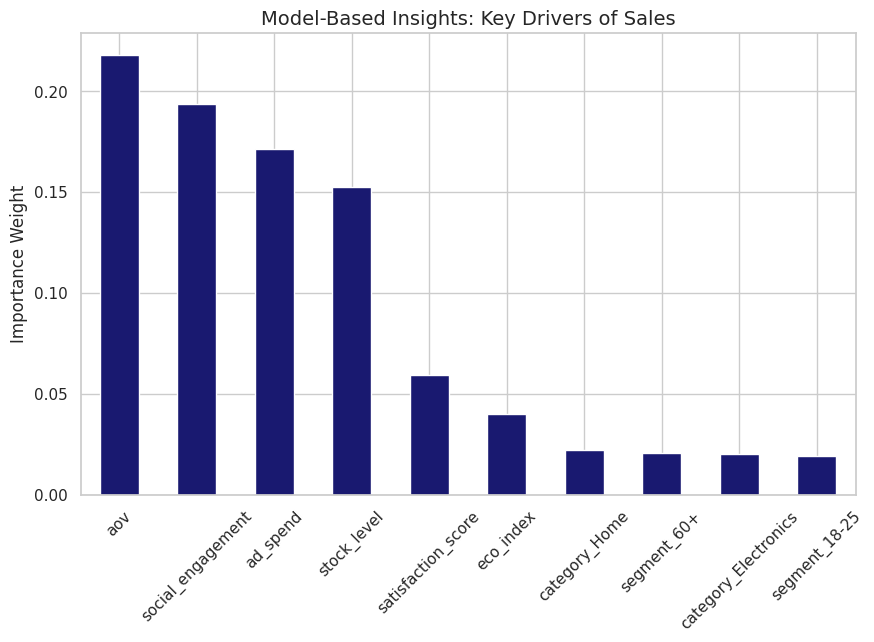

In [21]:
# 1. Evaluate accuracy
predictions = model.predict(X_test)
print(f"Model R2 Score (Accuracy): {r2_score(y_test, predictions):.2f}")

# 2. Visualize Feature Importance
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
importances.plot(kind='bar', color='midnightblue')
plt.title('Model-Based Insights: Key Drivers of Sales', fontsize=14)
plt.ylabel('Importance Weight')
plt.xticks(rotation=45)
plt.show()

> ⚠️ Note on Model Performance  
> The model is used for directional insight into key sales drivers rather than precise prediction.  
> Negative R² indicates high variance and complex, non-linear relationships common in marketing data.  
> Business decisions should prioritize relative importance, not point forecasts.

### **3.3 Strategic Sensitivity Analysis (The 'What-If' Tool)**

This final step uses the model for **Inference**. We perform a **Sensitivity Analysis** by simulating a 20% increase in the advertising budget.

By observing how the predicted sales change, we can measure the 'Elasticity' of our revenue. This allows management to test different budget scenarios and see the projected growth before spending a single dollar. It moves the business from guessing to data-driven planning.

In [16]:
# Quick test: If we increase Ad Spend by 20%, what happens to sales?
sample_data = X_test.iloc[0:1].copy()
original_pred = model.predict(sample_data)[0]

sample_data['ad_spend'] = sample_data['ad_spend'] * 1.20 # 20% Increase
new_pred = model.predict(sample_data)[0]

print(f"Original Sales Forecast: ${original_pred:.2f}")
print(f"Forecast after 20% Ad Spend Increase: ${new_pred:.2f}")
print(f"Projected Growth: {((new_pred - original_pred)/original_pred)*100:.2f}%")

Original Sales Forecast: $248.29
Forecast after 20% Ad Spend Increase: $278.63
Projected Growth: 12.22%


### Scenario Analysis: Ad Spend Sensitivity

This what-if analysis estimates the directional impact of increasing ad spend
by 20%, assuming other business conditions remain constant.

The results are indicative rather than predictive and are intended to support
budget allocation decisions by comparing relative outcomes across scenarios,
not to provide exact sales forecasts.

## **Final Summary & Strategic Insights**

This project developed an end-to-end **Omni-Channel Marketing Intelligence framework** combining SQL-driven metrics, exploratory data analysis, model-based driver insights, and scenario simulations to support data-driven marketing and operational decisions.

Rather than focusing solely on prediction accuracy, the analysis prioritizes **business interpretability, efficiency measurement, and actionable recommendations**, which better reflect real-world marketing analytics use cases.

## **Key Business Insights**

### 1. Marketing Efficiency Drives Revenue More Than Spend Volume
- Sales demonstrate stronger alignment with **ROAS and efficiency metrics** than with raw ad spend.
- Increasing spend without efficiency optimization leads to **diminishing returns**, increasing the risk of budget inefficiency.

**Implication:** Marketing budgets should be optimized around **return efficiency**, not absolute spend growth.

### 2. Product Categories Exhibit Unequal Profitability
- Certain product categories consistently outperform others in ROAS, acting as **profit engines**.
- Underperforming categories consume marketing budget without proportional revenue contribution.

**Implication:** Strategic budget reallocation toward high-performing categories can improve overall returns without increasing total spend.

### 3. Engagement Volume Alone Is Not a Reliable Growth Indicator
- High social engagement does not consistently translate into increased customer satisfaction or sales.
- Engagement quality and efficiency are more informative than raw interaction counts.

**Implication:** Social media strategies should prioritize **targeted, high-quality engagement** over volume-driven campaigns.

### 4. Model-Based Driver Analysis Supports Directional Decision-Making
- Feature importance analysis highlights **Average Order Value, ad spend, engagement efficiency, and inventory availability** as key sales drivers.
- Due to noise and variance in sales data, the model is used for **directional insight rather than precise forecasting**.

**Implication:** Machine learning serves as a **decision-support tool**, not a deterministic forecasting engine.

### 5. Scenario Analysis Enables Budget Sensitivity Evaluation
- A simulated 20% increase in ad spend resulted in an approximate **12% model-implied sales uplift**, assuming other conditions remain constant.
- This demonstrates the usefulness of scenario analysis for comparing **relative outcomes** across budget strategies.

**Implication:** Scenario tools are effective for **planning and sensitivity analysis**, even when exact predictions are uncertain.

## **Operational & Strategic Recommendations**

1. Reallocate marketing budget toward **high-ROAS product categories** and reduce spend on consistently underperforming segments.
2. Track **marketing efficiency metrics** (ROAS, social efficiency) alongside revenue to avoid diminishing returns.
3. Refine social strategies to emphasize **engagement quality and customer satisfaction** rather than interaction volume.
4. Use **scenario analysis** to evaluate the directional impact of budget changes rather than relying on point forecasts.
5. Incorporate **operational signals** such as inventory health into marketing planning to align demand generation with supply readiness.

## **Conclusion**

This project illustrates how marketing data can be transformed into **actionable business intelligence** by integrating descriptive analytics, efficiency diagnostics, model-based insights, and scenario evaluation.

By emphasizing **interpretability, business relevance, and decision support**, the framework mirrors real-world analytics practices and enables more informed marketing and operational decision-making.
